<img src="media/Banner_waterlevel+esalogo.svg" width="100%" alt="Banner for EO AFRICA course" />


*R. Rietbroek, May 2026*

<font color=#cf0072>

# Water Balance tutorial for the larger Rufiji Basin
</font>

<font color=#cf0072>
    
## Introduction and goal of the tutorial
Simplified, the water balance of an entire catchment can be approximated with a bucket model which fullfils the water balance equation:

$$\frac{d TWS}{dt}= P-ET - R$$

Which describes how the change in terrestrial water storage over the entire catchment, $\frac{d TWS}{dt}$ is fed by precipitation, $P$, and decreases through losses by evapotranspiration, $ET$ and (river) runoff. In this formulation we have ignored the contributions from subsurface groundwater, and non-river surface runoff for simplicity.  The above equation is provided in terms of mass per time unit, but it can also expressed in a volumetric unit, when prescribing the density of water, in e.g. $m^{3}/s$, which is commonly used to express river discharge.

The water balance equation allows the retrieval of one component from the 2 other components. However, since components are never perfectly known, the errors in the inferred component are a combination of the errors from the 2 input components.

# Goal
In this assignment, you will use GRACE and GRACE follow-on data to compute a time series of $\frac{d TWS}{dt}$ averaged over the Zambezi catchment. Using a $P-ET$ estimate from ERA5 data, and estimate of  $R$ at the mouth of the Zambezi will be obtained.

The inferred discharge will be compared with water level variations from radar altimetry, and discharge from the [GEOGLOWS model](https://www.geoglows.org/).  You will be asked to reflect on the results and discuss the possible error sources.

</font>

<font color=#cf0072>

## Step 1 (~500 words): Introduction
1. Write a short introduction on the purpose of this notebook aimed at fellow students. Make sure to also describe the characteristics of the RUFIJI catchment, and it's socio-economic and ecological roles.
2. Provide a flow chart of its working

### Hints & Tips
* You can create a flowchart with an external program and embed it in the markdown cell below

</font>

.. YOUR ANSWER ...

<font color=#cf0072>

## Step 2: Load the necessary modules

### Hints & Tips
* Are all modules, needed for this exercise, present? (i.e. you can restart and rerun the entire exercise in the specified order to check)
* Besides the standard modules (os etc.) do you motivate why some special modules are needed?

</font>


In [12]:
## ANSWER MODEL STEP2
import xarray as xr
# we need shxarray to perform computations on the Stokes coefficients from GRACE
import shxarray
import geopandas as gpd
from glob import glob
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import folium

<font color=#cf0072>

## Step 3: Load the catchment polygon, and convert it to a mask expressed in spherical harmonical basin coefficients

### Hints and tips
* Use a [geopandas.Geodataframe](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html) to read the `basin` layer from the polygon file: `Zambezi_geometry.gpkg`
* The above file holds multiple catchments, make sure to select the one related to the Zambezi
* [This example notebook](https://shxarray.wobbly.earth/latest/notebooks/Geometry2sphericalHarmonics.html) contains example code to convert a polygon to a set of spherical harmonic basin coefficients (i.e. a spectral representation of the basin which we will use later to average GRACE data.
* In particular the function `xr.DataArray.sh.from_geoseries` can be used for this (thus function internally uses [shxarray's polygon2sh function](https://shxarray.wobbly.earth/latest/references/shxarray.geom.polygons.html#shxarray.geom.polygons.polygon2sh)).
* Use a maximum degree which is consistent with the GRACE data (`nmax=96`)
* Also create a variable which holds the area of the Zambezi basin in [m<sup>2</sup>] (you need it later)
</font>


In [4]:
## ANSWER MODEL STEP 3
zambezi_gpkg_file='data/Zambezi_geometry.gpkg'
dfzambezi=gpd.read_file(zambezi_gpkg_file,layer='basin')

zambezi_area_m2=dfzambezi.UP_AREA.item()*1e6

display(zambezi_area_m2)


1378121100000.0

In [5]:
## ANSWER MODEL STEP 3 cont'd
#convert to a spherical harmonic file
nmax=96
nmin=2
dazambezi=xr.DataArray.sh.from_geoseries(dfzambezi.geometry,nmax=nmax,engine='shtns')

[SHTns 3.7.4] built Dec 11 2025, 14:03:49, id: avx512,ishioka,openmp


shxarray-INFO: Masking and gridding polygons
shxarray-INFO: Applying SH analysis


<font color=#cf0072>

## Step 4: Load the GRACE and GRACE-FO solutions, and a static gravity field (GOCO06S) catchment polygon, and convert it to terrestrial water storage

### Hints and tips
* Data with time variable gravity Stokes coefficients are listed in `monthly_n96`. You can use the [glob.glob](https://docs.python.org/3/library/glob.html), to generate a list of filenames. Make sure to check that the filenames are listed in chronological order and use a [sorting](https://docs.python.org/3/howto/sorting.html) if needed. Use [xarray.open_mfdataset](https://docs.xarray.dev/en/stable/generated/xarray.open_mfdataset.html) to open the list of files names and specify `engine='icgem'` as the loading engine.
* The static gravity field is provided in the file `GOCO06s.gfc.gz`.
* For debugging, you can use `display(ds_xxx)` to explore the different DataArray variables, coordinates and indexes in a dataset. The Stokes coefficients are found in the `xarray.Dataset` as `xarray.DataArray`'s named `cnm`.
* You can rebuild the spherical harmonic index, after e.g. reading coefficients from the files with `dsgrace=dsgrace.sh.build_nmindex()`
* Create anomalies of the GRACE/GRACE-FO coefficients by subtracting the static gravity. You can do this by truncating both datasets to maximum and minimum degrees `nmax=96, nmin=1` (i.e. apply the [`~~.sh.truncate(...)` accessor](https://shxarray.wobbly.earth/latest/references/shxarray.core.shxarbase.html#shxarray.core.shxarbase.ShXrBase.truncate) before subtracting.
* Converting the anomaly can be done using the [`~~.sh.tws(...)` accessor](https://shxarray.wobbly.earth/latest/references/shxarray.core.xr_accessor.html#shxarray.core.xr_accessor.SHDaAccessor.tws). You probably need to specify `ingravtype='stokes'` as an argument to tws to ensure that the input is interpreted as unitless Stokes coefficients
</font>


In [6]:
## ANSWER MODEL STEP 4
grcfiles=glob('data/monthly_n96/*gz')

dsgrace=xr.open_mfdataset(grcfiles,engine='icgem').sh.build_nmindex().sh.truncate(nmax,nmin)

# load static gravity field
gravstatic='data/GOCO06s.gfc.gz'
dsgravstatic=xr.open_dataset(gravstatic,engine='icgem').sh.build_nmindex().sh.truncate(nmax,nmin)

In [7]:
## ANSWER MODEL STEP 4
dadeltacnm=(dsgrace.cnm-dsgravstatic.cnm)
datws=dadeltacnm.sh.tws(ingravtype='stokes').compute()

shxarray-INFO: /home/roelof/.cache/shxarray_storage/Love/geoslurp_dump_llove.sql already exists, no need to download)
shxarray-WARNING: Thin shell approximation is used (surface load assumed)


<font color=#cf0072>

## Step 5: Compute the basin averages of the terrestrial water storage

Basin averages expressed as a uniformlayer of equivalent water height can be computed entirely in the spectral domain (see e.g. [Swenson and Wahr 2002](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2001JB000576)).

$$\overline{TWS}(t)=\frac{1}{B_{00}}\sum_{n=0}^{n=nmax}\sum_{m=-n}^{m} B_{nm} \tilde{T}_{nm} (t)$$

Here $B_{nm}$ are the basin coefficients from step 3, and $\tilde{T}_{nm}$ are the (filtered) spherical harmonic coefficients of terrestrial water storage coefficients from step 4. This operation is implement in `shxarray` where the filter can be supplied on the fly. For example:

`dabasin_mean=datws.sh.basinav(dabasincoef,filter='DDK6')`

computes the basin average for all time points of the terrestrial water storage coefficients datws `DataArray` in the basin represented by the coefficients $B_{nm}$.


### Hints and tips
* You can try different filters (e.g. `filter='DDK5','DDK6','DDK7','Gauss400'`) and find one which does not damp the seasonal amplitude too much while keeping the time series not too noisy.
</font>


In [8]:
## ANSWER MODEL STEP 5
leakage_corr='vishwa2017'
# dabuzi_grc=datws.sh.basinav(dabuzi,filtername=filter,engine='shtns')
# dabuzi2_grc=datws.sh.basinav(dabuzi,filtername=filter,leakage_corr=leakage_corr,engine='shtns')


# dabuzi_grc_ddk6=datws.sh.basinav(dabuzi,filtername=filter,engine='shtns')
# dabuzi2_grc_ddk6=datws.sh.basinav(dabuzi,filtername=filter,leakage_corr=leakage_corr,engine='shtns')
dazambezi_grc_ddk6=datws.sh.basinav(dazambezi,filtername='DDK6',engine='shtns')
dazambezi_grc_leak_ddk6=datws.sh.basinav(dazambezi,filtername='DDK6',leakage_corr=leakage_corr,engine='shtns')

dazambezi_grc_ddk7=datws.sh.basinav(dazambezi,filtername='DDK7',engine='shtns')
dazambezi_grc_leak_ddk7=datws.sh.basinav(dazambezi,filtername='DDK7',leakage_corr=leakage_corr,engine='shtns')

<font color=#cf0072>

## Step 6: Compute the  time derivatives of the terrestrial water storage, and visualize the computed TWS storages and flux

The basin averages from Step 5, represent storage anomalies. In order to derive the rate of change of the the TWS anomalies you still need to apply a numerical differentiation in time. A simple approximation is using [central differences](https://patrickwalls.github.io/mathematicalpython/differentiation/differentiation/):

$$\frac{d\overline{TWS}(t_{i})}{dt} \approx = \frac{1}{2}\left(\frac{\overline{TWS}(t_{i})-\overline{TWS}(t_{i-1})}{t_{i}-t_{i-1}}+\frac{\overline{TWS}(t_{i+1})-\overline{TWS}(t_{i})}{t_{i+1}-t_{i}}\right)$$ 

For the visualization part:
* In each plot, plot at least two filter versions to compare
* Annotate the figures with titles and axes with correct units and labels
* Use a legend to distinguish between lines

### Hints and tips
* Use the central differences implementation from [xarray](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.differentiate.html) (read the documentation and supply the correct arguments to the function!)
* Make sure to convert $\frac{d\overline{TWS}(t_{i})}{dt}$ (as uniform layer change in $m/s$ ) to volume $m^{3}/s$ using the area of the catchment
* You can use [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) to create a 2-panel figure to plot both the storage and flux.
</font>


In [9]:
## ANSWER MODEL STEP 6
da_zambezi_tws_rate_ddk7=zambezi_area_m2*dazambezi_grc_leak_ddk7.differentiate('time',datetime_unit='s')
da_zambezi_tws_rate_ddk6=zambezi_area_m2*dazambezi_grc_leak_ddk6.differentiate('time',datetime_unit='s')


Text(0, 0.5, 'm3/s')

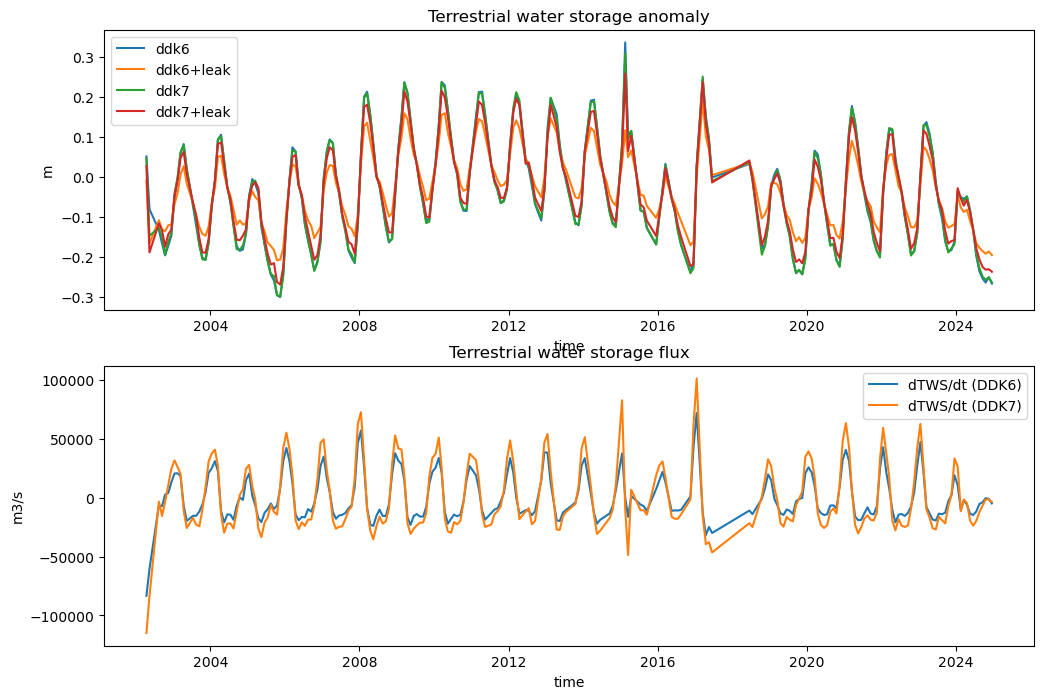

In [10]:
## ANSWER MODEL STEP 6 cont'd

fig,axes=plt.subplots(nrows=2,figsize=(12,8))
ax=axes[0]

dazambezi_grc_ddk6[0,:].plot(ax=ax,label='ddk6')
dazambezi_grc_leak_ddk6[0,:].plot(ax=ax,label='ddk6+leak')
dazambezi_grc_ddk7[0,:].plot(ax=ax,label='ddk7')
dazambezi_grc_leak_ddk7[0,:].plot(ax=ax,label='ddk7+leak')


# dabuzi2_grc_ddk7[0,:].plot(ax=ax,label='ddk7 +leak')
ax.legend()
ax.set_title('Terrestrial water storage anomaly')
ax.set_ylabel('m')

ax2=axes[1]

da_zambezi_tws_rate_ddk6.plot(ax=ax2,label='dTWS/dt (DDK6)')
da_zambezi_tws_rate_ddk7.plot(ax=ax2,label='dTWS/dt (DDK7)')

# da_p_min_et=(dspet_zambezi.avg_tprate-dspet_zambezi.avg_ie).interp(time=da_zambezi_tws_rate.time)

# da_p_min_et.plot(ax=ax,label='P-ET')


# da_inf_disch=(da_p_min_et-da_zambezi_tws_rate)
# da_inf_disch.plot(ax=ax,label='inferred discharge')

ax2.legend()

ax2.set_title('Terrestrial water storage flux')
ax2.set_ylabel('m3/s')


<font color=#cf0072>

## Step 7 (~500 words): Reflect on the found  GRACE/GRACE-FO time series of TWS and it's rate

In your discussion reflect on the following items:
* Explain how terrestrial water storage anomalies are linked to the gravity field
* Are the found values realistic (provide evidence from external sources)?
* What is the effect of filtering on the time series?
* What time variations can be found from the data (seasonal,inter-annual)? make quantifiable statements based on your data.


### Hints and tips
* Make quantifiable statements whereever possible
* In your answer provide the links to your online (reliable) sources.
</font>


... YOUR ANSWER ....

<font color=#cf0072>

## Step 8: Radar altimetry time series, and overview map

1. Load the geometries from `Zambezi_geometry.gpkg` and make an overview map
2. Load the radar altimetry time series from `Dahiti_waterlevel_zambezi.nc`
3. Select an appropriate virtual station which is representative for the outlet and motivate (in the comments) your choice in terms of location but also the amount of data points
4. Make sure that your chosen station is denoted on the map

### Hints and tips
* You can use [cartopy](https://cartopy.readthedocs.io/stable/gallery/index.html) or another plotting library of choice [e.g. Folium](https://geopandas.org/en/stable/gallery/polygon_plotting_with_folium.html)
</font>


In [64]:
## ANSWER MODEL STEP 8

dahiti_id=12200

zambezi_gpkg_file='data/Zambezi_geometry.gpkg'
dfdahiti_vstat=gpd.read_file(zambezi_gpkg_file,layer='dahiti_vstat')

plotcenter=dfzambezi.centroid

dfzambezi_river=gpd.read_file(zambezi_gpkg_file,layer='river')

m = folium.Map(location=[plotcenter.y, plotcenter.x], zoom_start=7)


for _,r in dfdahiti_vstat.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        popup=f"Dahiti_id: {r['dahiti_id']}").add_to(m)

# add basin geometry
basingjson=dfzambezi.geometry.to_json()
basingjson = folium.GeoJson(data=basingjson, style_function=lambda x: {"fillColor": "orange","color":"orange"})
folium.Popup("Catchment").add_to(basingjson)
basingjson.add_to(m)

# add river geometry
rivergjson=dfzambezi_river.geometry.to_json()
rivergjson = folium.GeoJson(data=rivergjson)
folium.Popup("Zambezi river").add_to(rivergjson)
rivergjson.add_to(m)

# folium.Marker(
#         location=[lat, lon],
#         popup="length: {} <br> area: {}".format(r["Shape_Leng"], r["Shape_Area"]),
#     ).add_to(m)
m

/tmp/ipykernel_11353/3319590171.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  plotcenter=dfzambezi.centroid
/home/roelof/cld_UTwente/Teaching/M-GEO5.0/Y1Q2_WaterCycle_Anthropocene/hydro-geodesy-edu-git/waterbalance/pytws/lib/python3.13/site-packages/folium/utilities.py:103: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(coord)
/home/roelof/cld_UTwente/Teaching/M-GEO5.0/Y1Q2_WaterCycle_Anthropocene/hydro-geodesy-edu-git/waterbalance/pytws/lib/python3.13/site-packages/folium/utilities.py:109: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  if math.isnan(float(coord)):
/home/roelof/cld_UTwente/Teaching/M-GEO5.0/Y1Q2_WaterCycle_Anthropocene/hydro-g

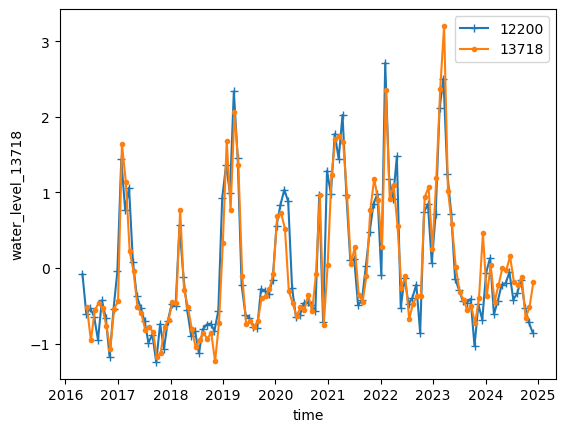

In [47]:
## ANSWER MODEL STEP 8 Cont'd
fdahiti='data/Dahiti_waterlevel_zambezi.nc'

daalt_zambezi=xr.open_dataset(fdahiti,decode_times=True)


#load relevant altimetry data
dahids=[12200,13718]

wl_dict={}

for daid in dahids:
    wlvar=f'water_level_{daid}'
    dswl=daalt_zambezi[wlvar]-daalt_zambezi[wlvar].mean()
    dswl=dswl.rename({f'time_{daid}':"time"})
    wl_dict[daid]=dswl

wl_dict[12200].plot(marker='+',label='12200')
wl_dict[13718].plot(marker='.',label='13718')
plt.legend()


<font color=#cf0072>

## Step 9: Load P-ET ERA5 time series, create and inferred discharge estimate from the water balance equation
1. Load the P, ET data from `era5_prec_evap_flux_storage.nc` variables (P=`avg_tprate`,ET=`avg_ie`) and select the Zambezi time series.
2. Interpolate the P-ET tiem series on the dTWS /dt time series and infer a discharge estimate
3. For comparison purposes, also load the auxiliary GEOGLOWS discharge data from `geoglows_daily_retrospective_120767686.csv`

### Hints and tips
* Note: the number in the geoglows file refers to the [river_id](https://hydroviewer.geoglows.org)
* The csv file can be read using with Pandas and turned into a `xarray.DataArray` using the `to_xarray` member function 
</font>


In [70]:
pet_file='data/era5_prec_evap_flux_storage.nc'
dspet=xr.open_dataset(pet_file).sel(basin='ZAMBEZI')

da_zambezi_pet=dspet.avg_tprate-dspet.avg_ie

da_dis_inferred=da_zambezi_pet.interp(time=da_zambezi_tws_rate_ddk7.time)-da_zambezi_tws_rate_ddk6
display(da_dis_inferred)

<xarray.DataArray (time: 239, id: 1)> Size: 2kB
array([[143650.47619621],
       [ 90384.93645297],
       [ 31796.99661574],
       [ 45313.63242575],
       [ 66369.5914301 ],
       [118960.88277196],
       [146925.14398471],
       [152121.71772726],
       [154960.04226807],
       [110145.9254848 ],
       [ 66197.87282106],
       [ 50644.46939708],
       [ 36819.94468824],
       [ 38201.3976535 ],
       [ 47251.89255423],
       [ 71996.07949064],
       [114588.6350141 ],
       [149712.07566649],
       [155900.4367766 ],
       [132663.10976157],
...
       [ 51140.16313602],
       [ 44664.9631808 ],
       [ 36716.13970745],
       [ 39212.33045526],
       [ 48419.820669  ],
       [ 65564.65345939],
       [115260.25471681],
       [149426.09852543],
       [138327.32197476],
       [116559.76801242],
       [ 96050.03247788],
       [ 66318.07111951],
       [ 43394.43968842],
       [ 37968.6044356 ],
       [ 32850.33744986],
       [ 26702.1733922 ],
       [ 33400.47831189],
       [ 65214.87401032],
       [104296.6226967 ],
       [162234.20728926]])
Coordinates:
  * time        (time) datetime64[ns] 2kB 2002-04-15T12:00:00 ... 2024-12-15T...
  * id          (id) int64 8B 0
    number      int64 8B 0
    basin       <U39 156B 'ZAMBEZI'
    basin_area  float64 8B 1.378e+12
    expver      (time) <U4 4kB '0001' '0001' '0001' ... '0001' '0001' '0001'

In [60]:
#Get Geoglows river discharge at  the nearest altimetry location
# river_id=120366780
# river_id=120726205
#zambezi
river_id=120767686

geoglowstseriesf=f'data/geoglows_daily_retrospective_{river_id}.csv'
# geoglowstseriesf='data/geoglows_hourly_retrospective_{river_id}.csv'
# geoglowstseriesf=f'data/geoglows_monthly_retrospective_{river_id}.csv'


dfgeoglows=pd.read_csv(geoglowstseriesf,sep=',',index_col='time').rename(columns={str(river_id):"discharge"})
dageoglows=dfgeoglows[dfgeoglows.index > '2016-01-01'].to_xarray()
dageoglows['time']=np.array(dageoglows.time.data,dtype='datetime64[ns]')
display(dageoglows)

/tmp/ipykernel_11353/54231496.py:14: UserWarning: no explicit representation of timezones available for np.datetime64
  dageoglows['time']=np.array(dageoglows.time.data,dtype='datetime64[ns]')


<xarray.Dataset> Size: 58kB
Dimensions:    (time: 3628)
Coordinates:
  * time       (time) datetime64[ns] 29kB 2016-01-01 2016-01-02 ... 2025-12-06
Data variables:
    discharge  (time) float64 29kB 6.122e+03 6.294e+03 ... 4.606e+03 5.686e+03

<font color=#cf0072>

## Step 10 : Plot a time series of the inferred discharge, and GEOGLOWS with altimetry water level in the same plot
1. Appropriate label the x an (2) y axes, i.e. specify units

### Hints and tips
* Use a [twinx plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.twinx.html) to overlay discharge and water level in the same plot
* Limit the range of the x axis so only the relevant overlap is shown (where there is radar altimetry data)
</font>


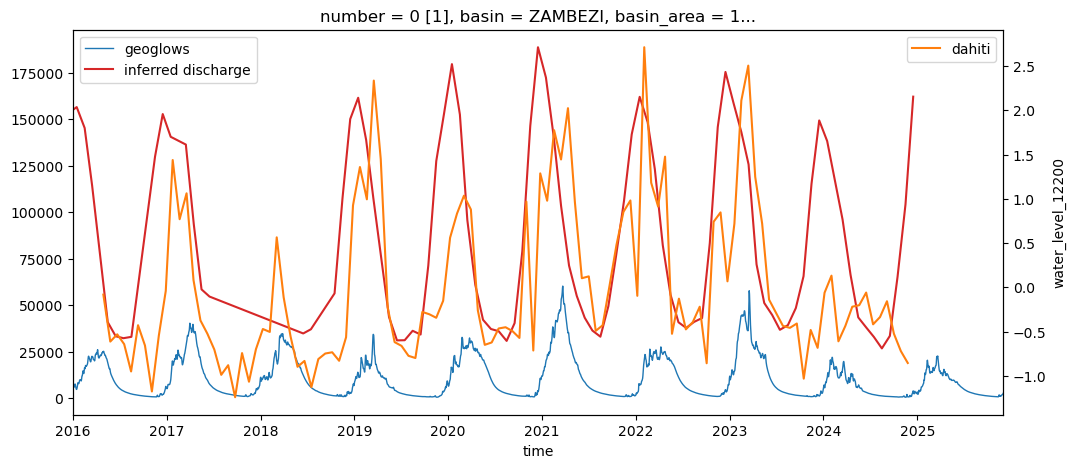

In [72]:
#interpolate geoglows on the altimetry points
fig,ax=plt.subplots(figsize=(12,5))

#dageoglows_alt=dageoglows.discharge.interp(time=daalt_buzi.time_18299,method='linear')
# dageoglows_alt.plot(ax=ax,label='geoglows interp',color='tab:blue')
(dageoglows.discharge).plot(ax=ax,label='geoglows',lw=1,color='tab:blue')
(da_dis_inferred).plot(ax=ax,label='inferred discharge',color='tab:red')
# daglofasdisch24.plot(ax=ax,color='tab:green',label='Glofas')
ax.set_xlim([np.datetime64('2016-01-01'),np.datetime64('2025-11-30')])
ax2=ax.twinx()
wl_dict[dahiti_id].plot(ax=ax2,color='tab:orange',label='dahiti')
ax2.legend()
ax.legend(loc='upper left')


<font color=#cf0072>

## Step 11 ( ~500 words ): Reflect on the found results, and discuss potential error sources in the input data and methods
In your reflection address the following points:
* Discuss the spatial and time resolution of the time series. To what extent are the (in)consistent?
* List potential error sources of the satellite gravimetry dTWS/dt time series
* List potential error sources of the satellite altimetry
* List error source in the P-ET time series
* Discuss the found discrepancies (offset,amplitudes, phases) between the inferred discharge and the GEOGLOWS model data.

### Hints and tips
* Refer to the lecture slides
* Make your statements quantifiable where possible
</font>
